In [1]:
import pandas as pd
dataset=pd.read_csv("Placement_Data_Full_Class.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [2]:
#1)Replace the NaN values with correct value. And justify why you have chosen the same.

In [3]:
df=dataset
df.isnull().sum()  ##Checking for Null values count in the dataset 

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [4]:
#Reasons behind choosing the method of replacing the salary value with constant '0' :

# 1.If we replace null values with either Mean Or Median or Mode, it changes the meaning of data as it implies
    ##the person is getting salary which is not true
# 2.If we delete the entire rows with Null values, we will miss the information from other columns which are not null
# 3.If we consider this as a SemiSuperivised problem and create model to predict the values and fill, again it changes the meaning 
    ##of data as it implies the person is getting salary which is not true
# 4.Incase if there are more number of columns with Null values, we could have used sklearn.SimpleImputer to fill the
    ##columns. Here we have only one column with Null values and again SimpleImputer also fills the data which will
    ## change the meaning of data
    
## 5.So the only way to keep the data meaningful is to replace Null values with 0, that can be acheived using below step
    

In [5]:
df['salary'].fillna(0,inplace=True)  ##Replacing Null values with constant '0'

In [6]:
df.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [7]:
##2)How many of them are not placed?

In [8]:
df=dataset

In [9]:
df[df["status"]== 'Not Placed']["status"].count()

67

In [10]:
df[df['status'] == 'Not Placed'].shape[0]

67

In [11]:
##3)Find the reason for non placement from the dataset?

In [12]:
"""
## The respective code is in in "DataScience_Assignment_Statsmodels_LogisticRegression.ipynb", conclusions are 
mentioned below.

The major reasons associated with non-placement are(with p_value<0.05):

Lower academic performance(ssc_p,hsc_p,degree_p)
Lack of work experience
Certain degree backgrounds(especially Sci&Tech)
MBA percentage showed a negative association with placement



Note: Work experience helps placements highly
"""

'\n## The respective code is in in "DataScience_Assignment_Statsmodels_LogisticRegression.ipynb", conclusions are \nmentioned below.\n\nThe major reasons associated with non-placement are(with p_value<0.05):\n\nLower academic performance(ssc_p,hsc_p,degree_p)\nLack of work experience\nCertain degree backgrounds(especially Sci&Tech)\nMBA percentage showed a negative association with placement\n\n\n\nNote: Work experience helps placements highly\n'

In [13]:
##4)What kind of relation between salary and mba_p

In [14]:
df=dataset
correlation = df['salary'].corr(df['mba_p'])
print(correlation)

0.13982273892615557


In [15]:
## This +0.139 value says there is weak positive(Low degree +ve) relationship between salary and mba_p columns.
## When one column value goes up the other also tend to go up but the data are highly scattered

In [16]:
##5)Which specialization is getting minimum salary?

In [17]:
df=dataset
df_filtered = df[df['salary'] != 0]
df_filtered.groupby('specialisation')['salary'].min()


specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64

In [18]:
### "Mkt&Fin" and "Mkt&HR" specializations are getting minimum salary 

In [19]:
##6)How many of them getting above 500000 salary?

In [20]:
df=dataset
df[df['salary'] > 500000].shape[0]

3

In [21]:
###7)Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.
###(Make decision using Hypothesis Testing)

In [22]:
## Ho- There is no significant difference between the scores of etest_p and mba_p
## H1- There is a significant difference between the scores of etest_p and mba_p

In [60]:
##OnewayClassification

from scipy.stats import stats
f_stat, p_value = stats.f_oneway(df['etest_p'], df['mba_p'])
#f_stat, p_value
print(f"F-Statistic: {f_stat}")
print(f"p-value: {p_value}")
# Make decision using the 5% significance level (0.05)
alpha = 0.05
if p_value <= alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("There is a significant difference between etest_p and mba_p scores.")
else:
    print("Conclusion: Accept the Null Hypothesis (H0).")
    print("There is no significant difference between etest_p and mba_p scores.")

F-Statistic: 98.64487057324706
p-value: 4.672547689133573e-21
Conclusion: Reject the Null Hypothesis (H0).
There is a significant difference between etest_p and mba_p scores.


In [24]:
##8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary 
##at significance level of 5%.(Make decision using Hypothesis Testing)

In [25]:
##Independent - Unpaired Ttest

## Ho-The mean scores of degree_t(Sci&Tech) and specialisation(Mkt&HR) are  similar, meaning there is no significant difference between the two groups.
## H1-The mean scores of degree_t(Sci&Tech) and specialisation(Mkt&HR) are not similar, meaning there is a significant difference between the two groups.

df=dataset

from scipy.stats import ttest_ind
degree=df[df["degree_t"]=='Sci&Tech']['salary']
specialisation=df[df['specialisation']=='Mkt&HR']['salary']
f_stat,p_value=ttest_ind(degree,specialisation)
print(f"F-Statistic: {f_stat}")
print(f"p-value: {p_value}")
alpha=0.05
if p_value<=alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("The mean scores of degree_t(Sci&Tech) and specialisation(Mkt&HR) are not similar, meaning there is a significant difference between the two groups.")
else:
    print("Conclusion: Accept the Null Hypothesis (H0).")
    print("The mean scores of degree_t(Sci&Tech) and specialisation(Mkt&HR) are similar, meaning there is no significant difference between the two groups.")

F-Statistic: 2.692041243555374
p-value: 0.007897969943471179
Conclusion: Reject the Null Hypothesis (H0).
The mean scores of degree_t(Sci&Tech) and specialisation(Mkt&HR) are not similar, meaning there is a significant difference between the two groups.


In [26]:
##9)Convert the normal distribution to standard normal distribution for salary column

In [27]:
df=dataset
df['salary'].fillna(0,inplace=True)
mean=df['salary'].mean()
std=df['salary'].std()
salary_zscore=[]
for values in df['salary']:
    z=round((values-mean)/std ,2)
    salary_zscore.append(z)
print(salary_zscore)

## Simplest way## df['salary_zscore'] = (df['salary'] - df['salary'].mean()) / df['salary'].std()

[0.46, 0.01, 0.33, -1.28, 1.46, -1.28, -1.28, 0.34, 0.21, -1.28, 0.4, 0.33, -1.28, 0.12, -1.28, 0.01, 0.65, -1.28, -1.28, 0.24, 0.43, 1.26, 1.04, 0.65, 1.04, -1.28, 0.27, 0.43, 0.98, -1.28, 0.33, -1.28, 0.51, 0.4, -1.28, 0.65, -1.28, 0.78, 0.27, 1.37, 0.57, -1.28, -1.28, 0.65, 0.01, -1.28, -1.28, 0.03, 0.33, -1.28, 0.01, -1.28, -1.28, 1.62, 0.11, 0.14, 0.27, 1.04, 0.45, 0.43, 0.4, 0.65, 0.27, -1.28, 0.27, -1.28, 0.49, 0.49, -1.28, 0.49, 1.04, 0.27, 0.27, 0.12, 0.89, -1.28, 0.2, 1.95, 0.46, -1.28, 0.27, 0.65, -1.28, 0.65, 0.65, 1.3, 0.14, -1.28, 0.07, 0.07, 0.65, -1.28, 0.2, -1.28, 0.4, 1.43, 0.65, -1.28, 0.14, -1.28, -1.28, 1.17, 0.65, 0.27, 1.04, -1.28, -1.28, 0.01, 0.65, -1.28, 0.33, -1.28, 0.33, 0.53, 0.33, 0.11, 0.65, 0.27, 0.5, 4.79, -1.28, 0.33, 0.24, 0.27, 0.33, 0.98, 0.07, 0.33, 1.3, 0.33, -1.28, 1.04, 0.65, 0.33, 0.33, 0.01, -1.28, 0.17, 0.33, 0.14, 0.43, -1.28, 0.4, 0.65, -1.28, 1.3, 0.22, 0.65, 0.27, -1.28, 3.17, 0.46, 0.27, 0.91, 0.33, -1.28, 0.36, 0.65, -1.28, -1.28, 0.65,

In [28]:
##10)What is the probability Density Function of the salary range from 700000 to 900000?

In [29]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
df=dataset

def get_pdf_probability(dataset, startrange, endrange):
    # 1. Calculate the mean and standard deviation of the column
    mean = dataset.mean()
    std = dataset.std()
    
    # 2. Use the Cumulative Distribution Function (CDF) to find the area under the curve
    # This subtracts the area below the start from the area below the end
    probability = stats.norm.cdf(endrange, mean, std) - stats.norm.cdf(startrange, mean, std)
    
    return probability

get_pdf_probability(df, 700000 , 900000)

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00059732])

In [30]:
##11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at 
##significance level of 5%.(Make decision using Hypothesis Testing)

In [61]:
##Dependent - Paired Ttest

## Ho-The degree_t(Sci&Tech) with respect to etest_p and mba_p are similar, meaning there is no significant difference between the two groups.
## H1-The degree_t(Sci&Tech) with respect to etest_p and mba_p are not similar, meaning there is a significant difference between the two groups.

df=dataset

from scipy.stats import ttest_rel

degree=df[df['degree_t']=='Sci&Tech']['etest_p']
degree1=df[df['degree_t']=='Sci&Tech']['mba_p']
f_stat,p_value=ttest_rel(degree,degree1)
print(f"f_stat:{f_stat}")
print(f"p_value:{p_value}")

alpha=0.05
if p_value<=alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("The degree_t(Sci&Tech) with respect to etest_p and mba_p are not similar, meaning there is a significant difference between the two groups.")
else:
    print("Conclusion: Accept the Null Hypothesis (H0).")
    print("The degree_t(Sci&Tech) with respect to etest_p and mba_p are similar, meaning there is no significant difference between the two groups.")


f_stat:5.0049844583693615
p_value:5.517920600505392e-06
Conclusion: Reject the Null Hypothesis (H0).
The degree_t(Sci&Tech) with respect to etest_p and mba_p are not similar, meaning there is a significant difference between the two groups.


In [32]:
##12)Which parameter is highly correlated with salary?

In [33]:
import pandas as pd

df=dataset

corr_matrix = df.corr()

#  Isolate the "salary" column
salary_corr = corr_matrix['salary']

# Filter out "salary" matching with itself and apply threshold
threshold = 0.5
highly_correlated_with_salary = salary_corr[(salary_corr > threshold) & (salary_corr.index != 'salary')]

print("Columns highly correlated with 'salary':")
print(highly_correlated_with_salary)

Columns highly correlated with 'salary':
ssc_p    0.53809
Name: salary, dtype: float64


In [34]:
#Column "ssc_p" is moderately correlated(Low degree of +ve correlation) with column "Salary"

In [35]:
###13) plot any useful graph and explain it.

The area between the range(300000,400000):0.15969954548836973


0.15969954548836973

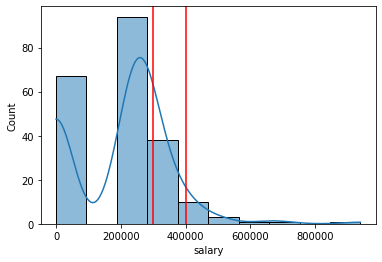

In [38]:

df=dataset

def get_pdf_probability(dataset, startrange, endrange):
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    from scipy.stats import norm
    import numpy as np
    import seaborn as sns
    
    ax=sns.histplot(dataset,kde=True)
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
     ##Calculate the mean and standard deviation of the column
    mean = dataset.mean()
    std = dataset.std()
    
    # 2. Use the Cumulative Distribution Function (CDF) to find the area under the curve
    # This subtracts the area below the start from the area below the end
    ## probability = stats.norm.cdf(endrange, mean, std) - stats.norm.cdf(startrange, mean, std)
    
    dist=norm(mean,std)
    ##sample probablities of range of outcomes
    values=[value for value in range(startrange,endrange)]
    probablities=[dist.pdf(value) for value in values]
    prob=sum(probablities)
    print("The area between the range({},{}):{}".format(startrange,endrange,prob))
    
    return prob

get_pdf_probability(df['salary'], 300000 , 400000)




In [ ]:
##The probablity of salary between 300000 and 400000 is 16%